In [1]:
import sys
import os
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns


# Добавляем корень проекта в пути поиска модулей
sys.path.append(os.path.abspath('..'))
%load_ext autoreload
%autoreload 2




In [2]:


# Загружаем данные (укажите ваш путь к файлу)
train_df = pd.read_csv('../data/raw/heart_train.csv')

print("--- Типы данных ---")
print(train_df.info())

print("\n--- Первые 5 строк ---")
print(train_df.head())

print("\n--- Пропуски ---")
print(train_df.isna().sum())

--- Типы данных ---
<class 'pandas.DataFrame'>
RangeIndex: 8685 entries, 0 to 8684
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       8685 non-null   int64  
 1   Age                              8685 non-null   float64
 2   Cholesterol                      8685 non-null   float64
 3   Heart rate                       8685 non-null   float64
 4   Diabetes                         8442 non-null   float64
 5   Family History                   8442 non-null   float64
 6   Smoking                          8442 non-null   float64
 7   Obesity                          8442 non-null   float64
 8   Alcohol Consumption              8442 non-null   float64
 9   Exercise Hours Per Week          8685 non-null   float64
 10  Diet                             8685 non-null   int64  
 11  Previous Heart Problems          8442 non-null   float64
 12  Medication 

• Таргет: Heart Attack Risk (Binary) (float, но по значениям 0/1).
• id: отдельная колонка id — нужна для файла предсказаний.
• Лишний индекс-столбец: Unnamed: 0 — это технический индекс, его надо удалить.
• Пропуски: ровно 243 пропуска в наборе бинарных/категориальных по смыслу признаков (Diabetes, Family History, Smoking, …). Их надо импутировать.
• Gender: строка (Male/Female) — кодировать.
• Все остальные признаки уже нормализованы в [0..1] (по первым строкам видно). Значит, скейлинг, вероятно, уже сделан заранее (но это не гарантирует отсутствие утечек — проверим позже).


• Мусорные признаки:
    • Unnamed: 0: Это просто дубликат индекса, его удаляем.
    • id: Как мы и договаривались, его храним для сабмита, но в модель не подаем.
• Пропуски (Missing Values):
    • У вас ровно 243 пропуска в целом ряде колонок (Diabetes, Smoking, Stress Level и др.). Скорее всего, это одни и те же 243 пациента.
    • Что делать: В ООП-классе предобработки нам нужно будет решить: либо удалить эти строки (если это <5% данных, а у нас 8685 строк, так что это всего ~2.8%), либо заполнить их модой/медианой.
• Типы данных:
    • Gender: Это единственная колонка типа str (Male/Female). Её нужно будет перекодировать (LabelEncoding или OneHotEncoding).
    • Heart Attack Risk (Binary): Это наш Target.
• Специфические медицинские признаки:
    • CK-MB и Troponin: Это ферменты, уровень которых резко растет при повреждении сердечной мышцы. Это очень важные признаки.
Systolic и Diastolic blood pressure: Уже разделены — это отлично!

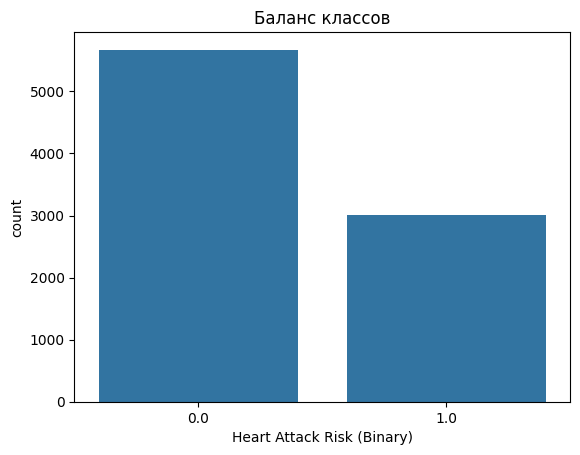

Heart Attack Risk (Binary)
0.0    0.65308
1.0    0.34692
Name: proportion, dtype: float64


In [9]:
# Распределение таргета
sns.countplot(x='Heart Attack Risk (Binary)', data=train_df)
plt.title('Баланс классов')
plt.show()

print(train_df['Heart Attack Risk (Binary)'].value_counts(normalize=True))

Анализ баланса классов
У нас 65% здоровых (0.0) и 35% в зоне риска (1.0).

Дисбаланс умеренный. Это не 99 к 1, где нужны сложные ухищрения.

Выбор метрики: Простая Accuracy (точность) здесь может быть обманчивой. Если модель просто предскажет всем "0", она получит 65% точности, но пропустит всех больных.

Стоит сфокусироваться на F1-Score (баланс между точностью и полнотой) или ROC-AUC. В медицине мы часто отдаем приоритет Recall (полноте), чтобы минимизировать риск пропустить реальный сердечный приступ.

02 Чистка данных

In [3]:
from src.heart_risk.features.transformer import HeartFeatureTransformer
from src.heart_risk.models.trainer import HeartModelTrainer

# Проверяем в деле
transformer = HeartFeatureTransformer()
transformer.fit(train_df)
train_cleaned = transformer.transform(train_df)

print(f"Форма данных после чистки: {train_cleaned.shape}")
print(f"Осталось пропусков: {train_cleaned.isna().sum().sum()}")

Форма данных после чистки: (8685, 26)
Осталось пропусков: 0


03 Data train

In [4]:
from src.heart_risk.models.trainer import HeartModelTrainer

# 1. Подготовка признаков и таргета
X = train_cleaned.drop(columns=['Heart Attack Risk (Binary)'])
y = train_cleaned['Heart Attack Risk (Binary)']

# 2. Инициализация и обучение
trainer = HeartModelTrainer(iterations=500)
y = y.astype(int)
model = trainer.train(X, y)

# 3. Оценка качества
print("Итоговые метрики на валидации:")
trainer.evaluate(X, y)

0:	learn: 0.6423240	test: 0.6312736	best: 0.6312736 (0)	total: 139ms	remaining: 1m 9s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6312736036
bestIteration = 0

Shrink model to first 1 iterations.
Итоговые метрики на валидации:
              precision    recall  f1-score   support

           0       0.73      0.24      0.37      5672
           1       0.37      0.83      0.51      3013

    accuracy                           0.45      8685
   macro avg       0.55      0.54      0.44      8685
weighted avg       0.61      0.45      0.42      8685



04 model

In [9]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split

# Создаем папку для модели, если её нет
os.makedirs('../artifacts', exist_ok=True)

# 1. Подготовка данных (используем уже очищенный train_cleaned)
X = train_cleaned.drop(columns=['Heart Attack Risk (Binary)'])
y = train_cleaned['Heart Attack Risk (Binary)'].astype(int)

# 2. Быстрое обучение "заглушки" для API
# Даже если метрика слабая, нам нужен файл .cbm для запуска сервера
model_to_save = CatBoostClassifier(
    iterations=100, # мало итераций для скорости
    learning_rate=0.05,
    scale_pos_weight=2.0,
    verbose=False,
    random_seed=42
)

model_to_save.fit(X, y)

# 3. Сохранение
model_path = '../artifacts/model.cbm'
model_to_save.save_model(model_path)

if os.path.exists(model_path):
    print(f"Успех! Модель сохранена по адресу: {os.path.abspath(model_path)}")
else:
    print("Ошибка: файл не был создан.")

Успех! Модель сохранена по адресу: c:\Users\d_dob\OneDrive\Personal\Code\yandex_heart_risk_project\artifacts\model.cbm
